# Lab 01 - Linear Regression with Gradient Descent
**Idea:** fit a line `y = θ0 + θ1·x`. Start with θ = [0, 0], measure the error (cost), and keep nudging θ downhill until the error stops shrinking.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.seterr(all='ignore')   # a too-big learning rate blows up to inf/nan; don't spam warnings

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

## 1. The functions
- `load_data` - read csv
- `process_data` - (optional) scale x, then add the dummy feature x0 = 1
- `compute_cost` - how wrong the line is
- `gradient_descent` - the learning loop
- `train` - start from θ = 0 and call gradient_descent
- `evaluate` - MSE and R²

In [7]:
def load_data(path):
    """Read csv -> x (feature), y (target). Last column is y."""
    df = pd.read_csv(path, header=None)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()   # a text header row becomes NaN and is dropped
    return df.iloc[:, 0].values, df.iloc[:, -1].values


def process_data(x, scale=False):
    """Optionally scale x, then add the dummy feature x0 = 1."""
    mean, std = 0, 1                        # default: no scaling
    if scale:
        mean, std = x.mean(), x.std()
    x_scaled = (x - mean) / std
    X = np.c_[np.ones(len(x)), x_scaled]    # column of 1s (x0) + column of x
    return X, mean, std


def compute_cost(X, y, theta):
    m = len(y)
    errors = X @ theta - y                  # predictions - actual values
    return (errors @ errors) / (2 * m)      # J = 1/(2m) * sum(errors^2)


def gradient_descent(X, y, theta, alpha, iters):
    m = len(y)
    costs = []
    for i in range(iters):
        gradient = X.T @ (X @ theta - y) / m    # slope of the cost
        theta = theta - alpha * gradient        # step downhill
        costs.append(compute_cost(X, y, theta))
    return theta, costs


def train(X, y, alpha, iters):
    theta = np.zeros(X.shape[1])            # start from [0, 0]
    return gradient_descent(X, y, theta, alpha, iters)


def evaluate(X, y, theta):
    pred = X @ theta
    mse = np.mean((y - pred) ** 2)
    r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
    return round(float(mse), 4), round(float(r2), 4)

## 2. Synthetic data: y = 3 + 5x + noise

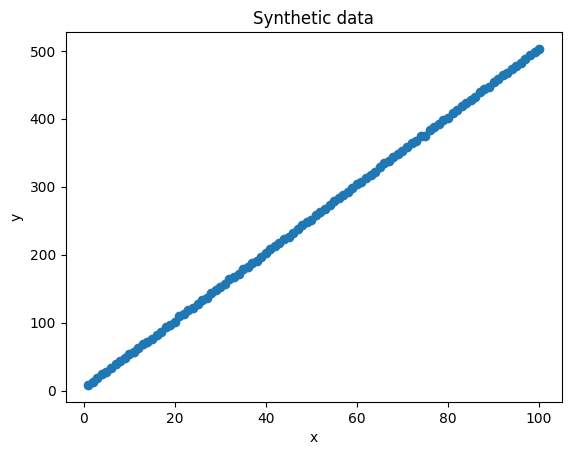

In [8]:
np.random.seed(42)
x = np.arange(1, 101)                       # x = 1, 2, ..., 100
y = 3 + 5 * x + np.random.randn(100)        # + standard gaussian noise

plt.scatter(x, y)
plt.xlabel('x'); plt.ylabel('y'); plt.title('Synthetic data')
plt.show()

pd.DataFrame({'x': x, 'y': y}).to_csv('lab01_data.csv', index=False)
x, y = load_data('lab01_data.csv')          # load it back

## 3. The full experiment in one function
1. **Without scaling** - try several learning rates, pick a working one, train
2. **With scaling** - train again
3. Plot the cost curves and the fitted line

In [9]:
def run_lab(x, y, alpha_raw, iters_raw=5000, alpha_scaled=0.1, iters_scaled=500):

    # ---------- A) WITHOUT feature scaling ----------
    X, mean, std = process_data(x, scale=False)

    print('Learning rate sweep (no scaling, 1000 iterations):')
    for a in [0.1, 0.01, 0.001, 0.0001, 0.00001]:
        _, c = train(X, y, a, 1000)
        print(f'   alpha = {a}: final cost = {c[-1]:.4f}')     # inf/nan = diverged

    theta, costs = train(X, y, alpha_raw, iters_raw)
    print(f'\nNo scaling (alpha={alpha_raw}): theta = {theta}')
    print('MSE, R2 =', evaluate(X, y, theta))
    plt.plot(costs); plt.xlabel('Iteration'); plt.ylabel('Cost')
    plt.title('Training error - no scaling'); plt.show()

    # ---------- B) WITH feature scaling ----------
    Xs, mean, std = process_data(x, scale=True)
    theta_s, costs_s = train(Xs, y, alpha_scaled, iters_scaled)

    # convert theta back to the original x units
    theta_orig = np.array([theta_s[0] - theta_s[1] * mean / std, theta_s[1] / std])
    print(f'\nWith scaling (alpha={alpha_scaled}): theta = {theta_s}')
    print('In original units: theta =', theta_orig)
    print('MSE, R2 =', evaluate(Xs, y, theta_s))
    plt.plot(costs_s); plt.xlabel('Iteration'); plt.ylabel('Cost')
    plt.title('Training error - with scaling'); plt.show()

    # ---------- C) Data + learned line ----------
    plt.scatter(x, y, label='data')
    plt.plot(x, Xs @ theta_s, 'r', label='learned line')
    plt.xlabel('x'); plt.ylabel('y'); plt.legend()
    plt.title('Data with regression line'); plt.show()

Learning rate sweep (no scaling, 1000 iterations):
   alpha = 0.1: final cost = nan
   alpha = 0.01: final cost = nan
   alpha = 0.001: final cost = nan
   alpha = 0.0001: final cost = 1.2943
   alpha = 1e-05: final cost = 1.3344

No scaling (alpha=0.0001): theta = [0.39386562 5.03769334]
MSE, R2 = (2.2714, 0.9999)


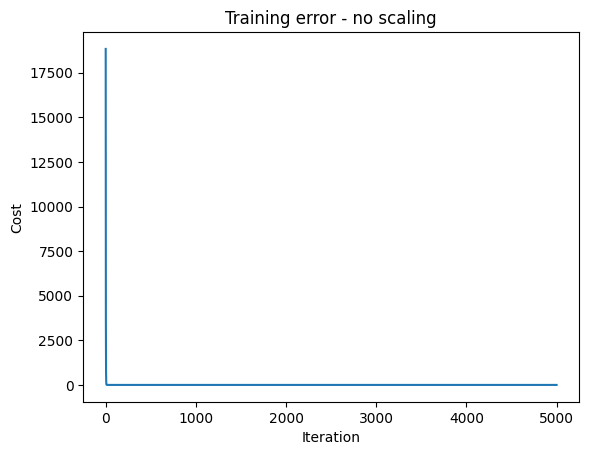


With scaling (alpha=0.1): theta = [255.39615348 144.37056816]
In original units: theta = [2.82579389 5.00139326]
MSE, R2 = (0.8149, 1.0)


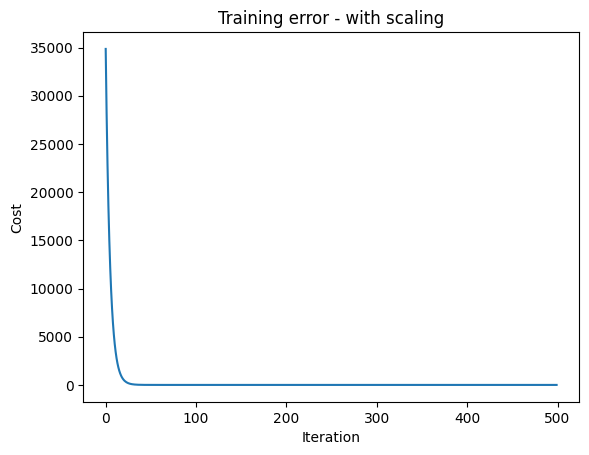

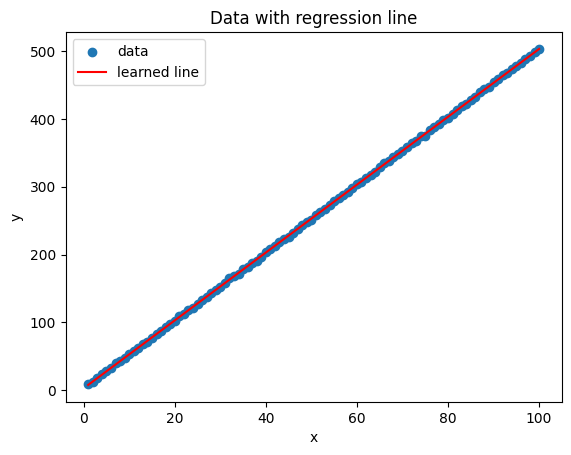

In [10]:
run_lab(x, y, alpha_raw=0.0001)

## 4. Real data (`data_01.csv`)
Upload the file, then run the same experiment. Change `alpha_raw` to the best value from the sweep output.

In [11]:
from google.colab import files
files.upload()          # choose data_01.csv

Saving data_01.csv to data_01 (1).csv


{'data_01 (1).csv': b'14.96,463.26\r\n25.18,444.37\r\n5.11,488.56\r\n20.86,446.48\r\n10.82,473.9\r\n26.27,443.67\r\n15.89,467.35\r\n9.48,478.42\r\n14.64,475.98\r\n11.74,477.5\r\n17.99,453.02\r\n20.14,453.99\r\n24.34,440.29\r\n25.71,451.28\r\n26.19,433.99\r\n21.42,462.19\r\n18.21,467.54\r\n11.04,477.2\r\n14.45,459.85\r\n13.97,464.3\r\n17.76,468.27\r\n5.41,495.24\r\n7.76,483.8\r\n27.23,443.61\r\n27.36,436.06\r\n27.47,443.25\r\n14.6,464.16\r\n7.91,475.52\r\n5.81,484.41\r\n30.53,437.89\r\n23.87,445.11\r\n26.09,438.86\r\n29.27,440.98\r\n27.38,436.65\r\n24.81,444.26\r\n12.75,465.86\r\n24.66,444.37\r\n16.38,450.69\r\n13.91,469.02\r\n23.18,448.86\r\n22.47,447.14\r\n13.39,469.18\r\n9.28,482.8\r\n11.82,476.7\r\n10.27,474.99\r\n22.92,444.22\r\n16.0,461.33\r\n21.22,448.06\r\n13.46,474.6\r\n9.39,473.05\r\n31.07,432.06\r\n12.82,467.41\r\n32.57,430.12\r\n8.11,473.62\r\n13.92,471.81\r\n23.04,442.99\r\n27.31,442.77\r\n5.91,491.49\r\n25.26,447.46\r\n27.97,446.11\r\n26.08,442.44\r\n29.01,446.22\r\n12.18,

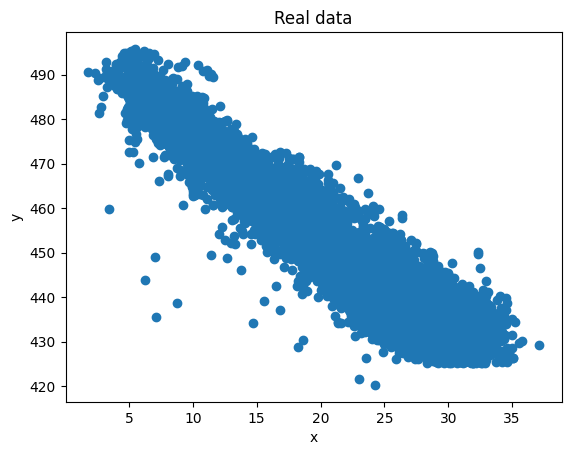

Learning rate sweep (no scaling, 1000 iterations):
   alpha = 0.1: final cost = nan
   alpha = 0.01: final cost = nan
   alpha = 0.001: final cost = 12054.5855
   alpha = 0.0001: final cost = 15105.7091
   alpha = 1e-05: final cost = 15462.7690

No scaling (alpha=0.001): theta = [232.10842193   9.61845397]
MSE, R2 = (8853.566, -29.3983)


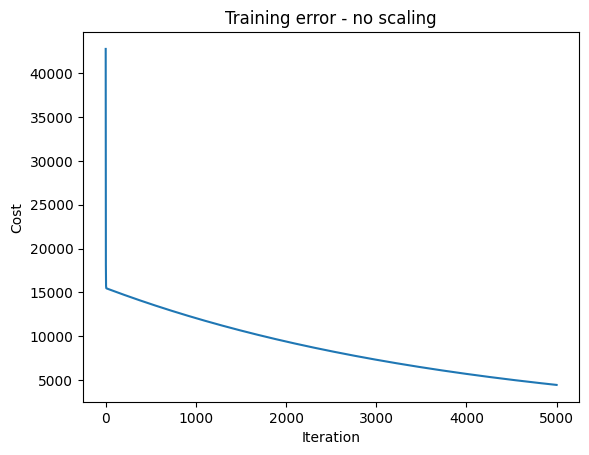


With scaling (alpha=0.1): theta = [454.36500941 -16.18085823]
In original units: theta = [497.03411989  -2.17131996]
MSE, R2 = (29.4317, 0.8989)


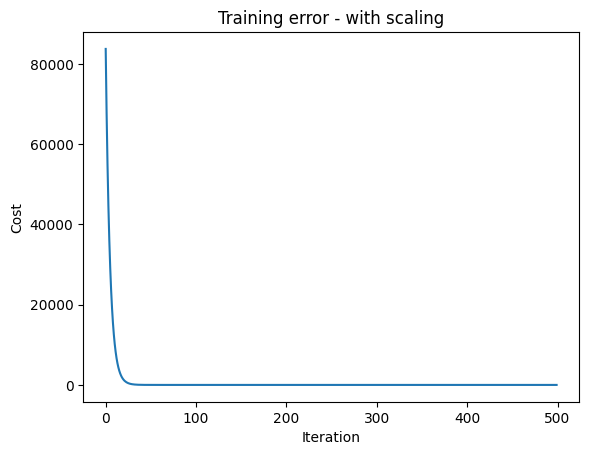

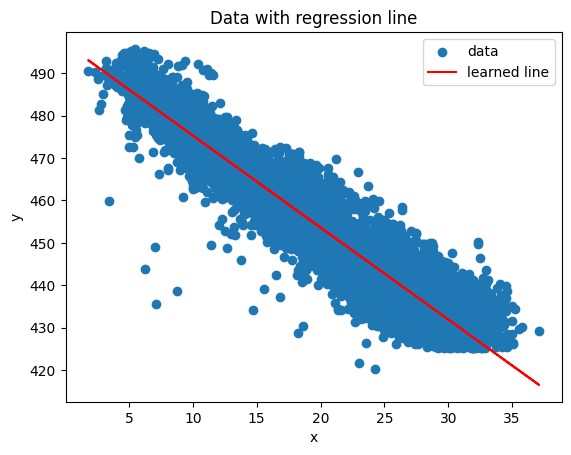

In [12]:
x_real, y_real = load_data('data_01.csv')

plt.scatter(x_real, y_real)
plt.xlabel('x'); plt.ylabel('y'); plt.title('Real data')
plt.show()

run_lab(x_real, y_real, alpha_raw=0.001)